In [1]:
import numpy as np
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_rhs
from dyn_modelling.methods.dmd import fit_dmd, reconstruct, reconstruct_analytic, get_eigenvalues, fit_hodmd, reconstruct_hodmd
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_dmd_reconstruction, plot_eigenvalues
from dyn_modelling.utils.data import add_noise


## 1. Build the lattice


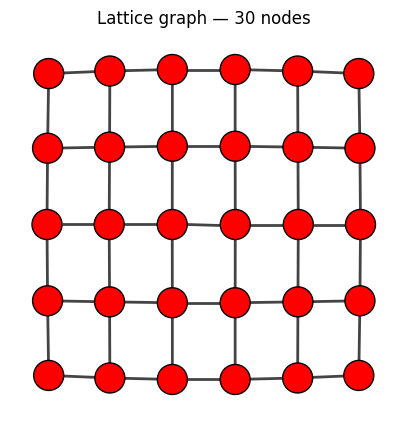

In [2]:
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice - single trajectory 

In [3]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 10.0, 100.0
t_end, n_steps = 100.0, 100
neigh_order = 2

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

## 3. Plot trajectories — clean data


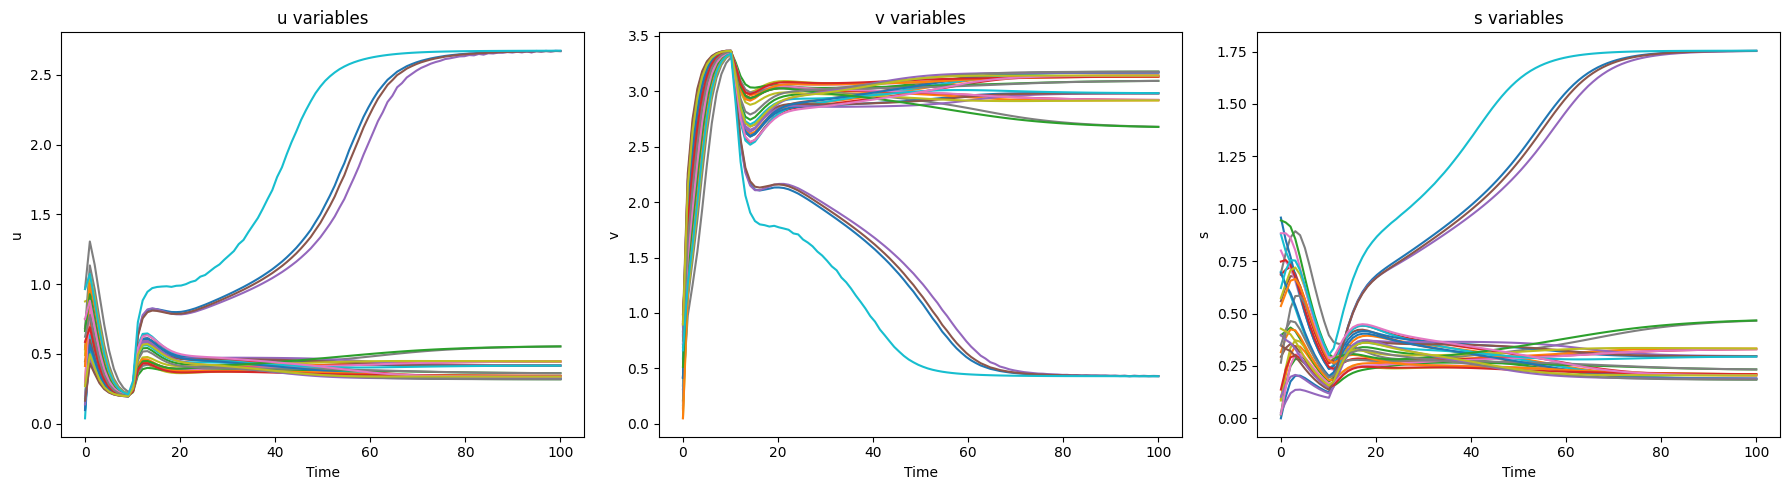

In [4]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


In [44]:
#y_noisy = add_noise(y, noise_level=0.1)
#plot_trajectories(t_eval, y_noisy)

## 5. DMD - clean data

In [5]:
## 4. Fit DMD — clean data
dmd_clean = fit_dmd(y, svd_rank=0)

X_rec_clean = reconstruct(dmd_clean)
X_ana_clean = reconstruct_analytic(dmd_clean, y)



d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 20953434054.77502. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


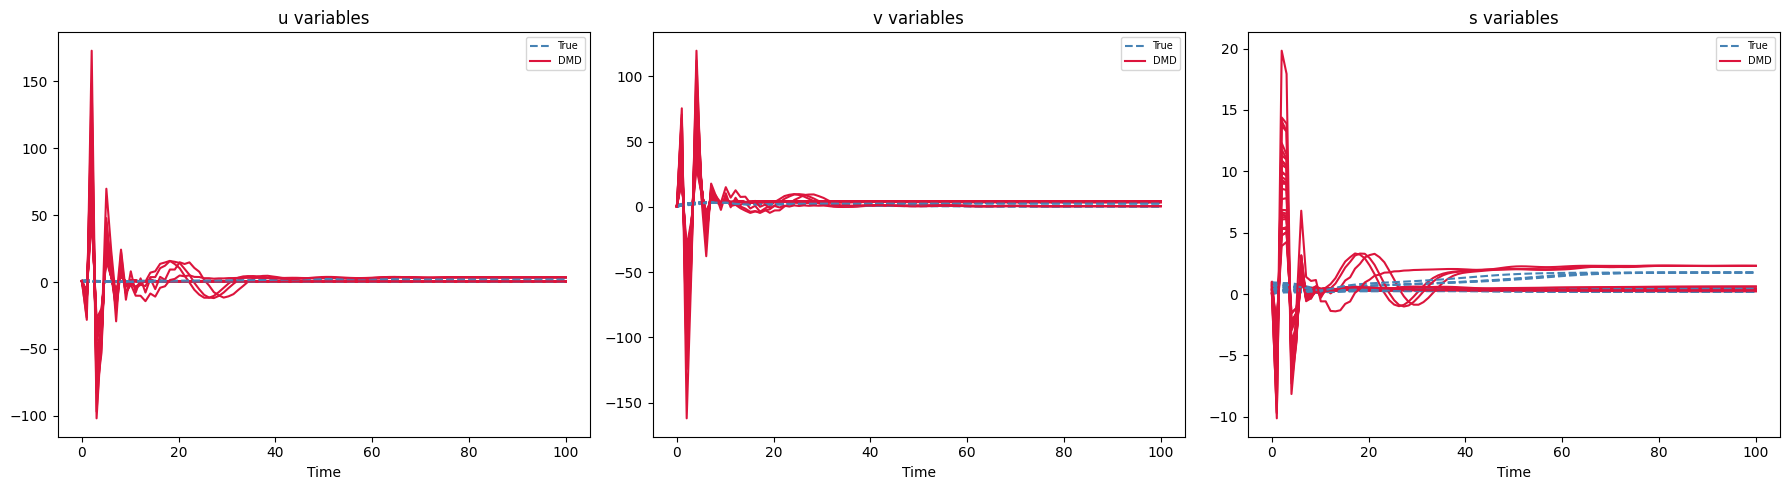

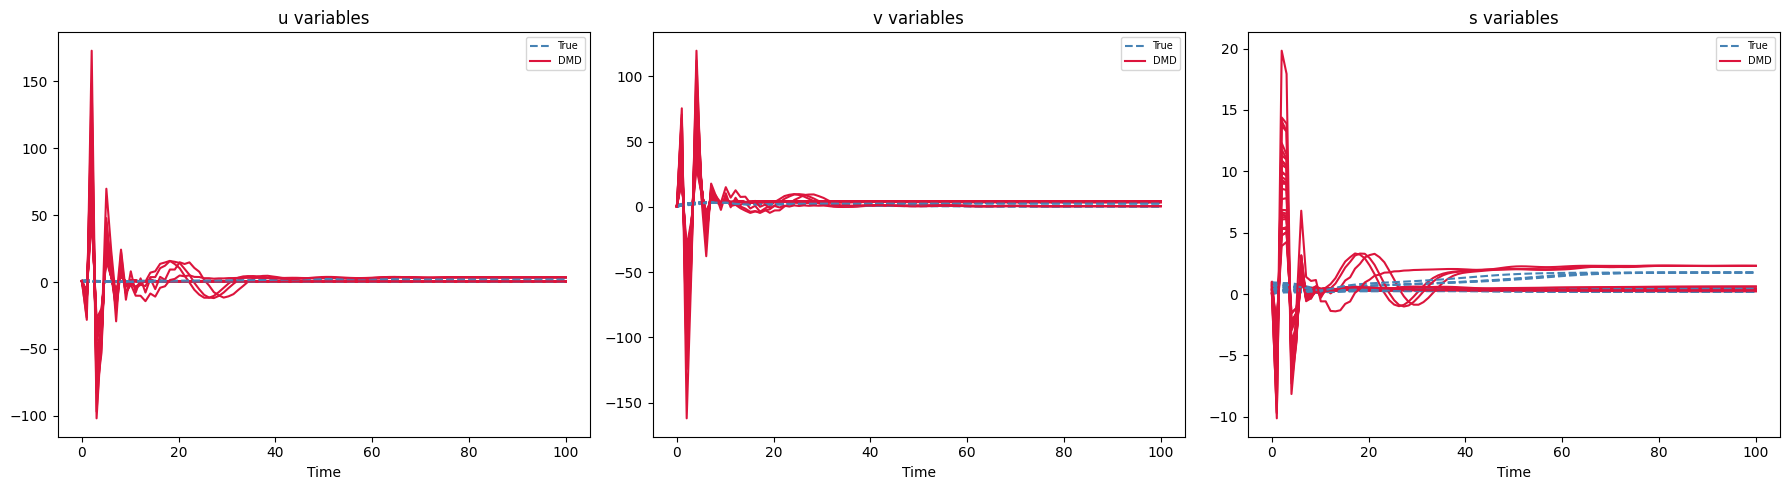

In [6]:
## 5. Plot reconstruction — clean
plot_dmd_reconstruction(t_eval, y.T, X_rec_clean, title="DMD reconstruction — clean")
plot_dmd_reconstruction(t_eval, y.T, X_ana_clean, title="Analytic DMD reconstruction — clean")

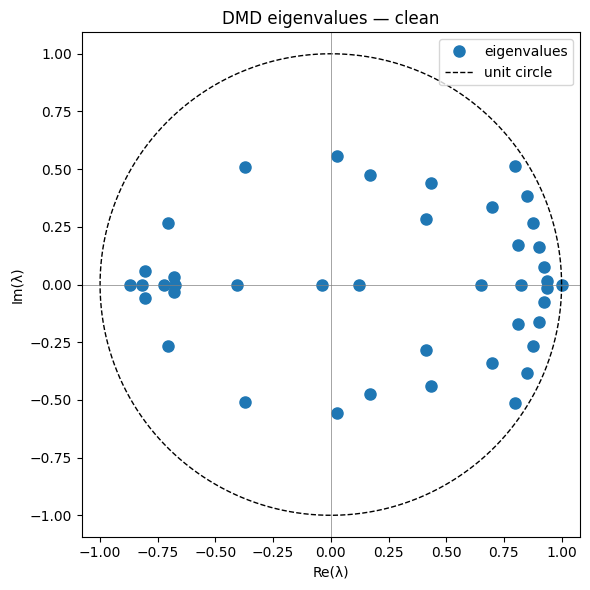

In [7]:
## 6. Plot eigenvalues — clean
plot_eigenvalues(get_eigenvalues(dmd_clean), title="DMD eigenvalues — clean")

## 6. HODMD - clean data

In [8]:
hodmd = fit_hodmd(y, svd_rank=0, d=10)
X_rec_hodmd = reconstruct_hodmd(hodmd)

d:\Projects\dyn-modelling\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 60128560.27906547. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


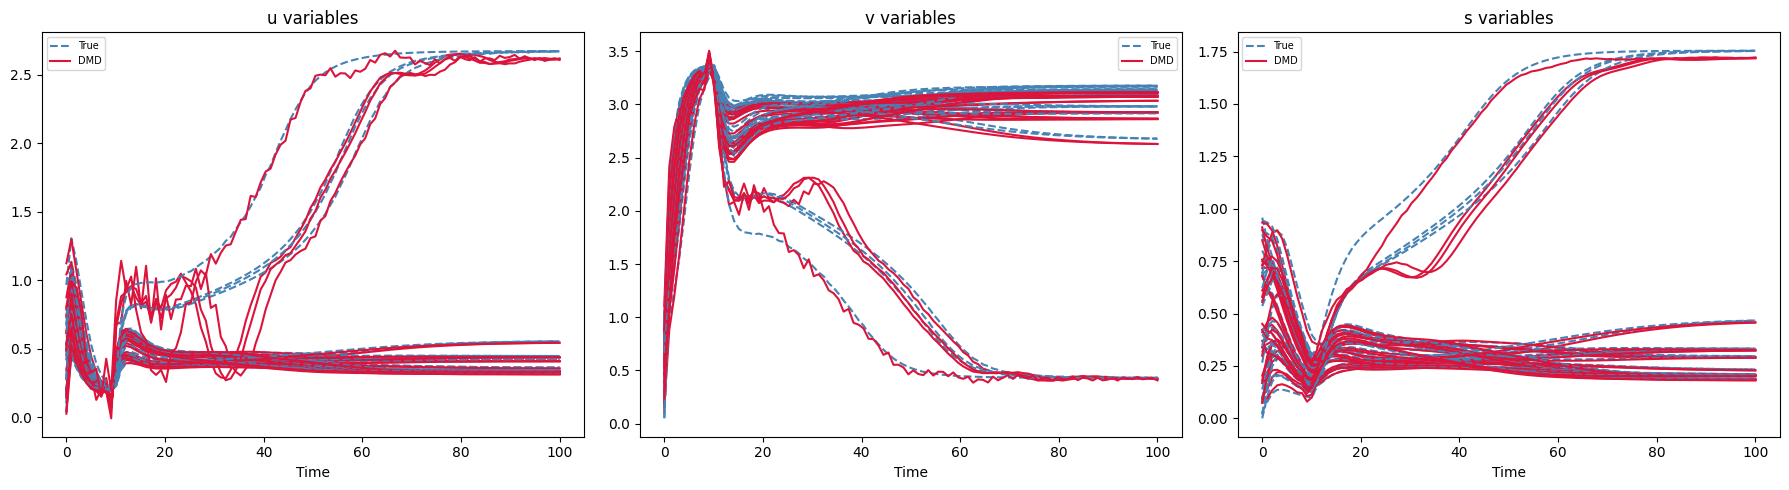

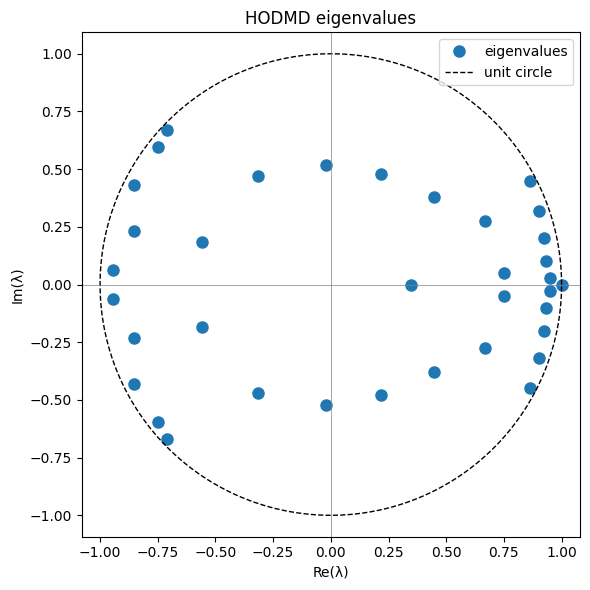

In [9]:
plot_dmd_reconstruction(t_eval, y.T, X_rec_hodmd, title="HODMD reconstruction")
plot_eigenvalues(get_eigenvalues(hodmd), title="HODMD eigenvalues")

## 6. DMD - noisy data

In [ ]:
## 7. Fit DMD — noisy data
y_noisy = add_noise(y, noise_level=0.05, seed=42)
plot_trajectories(t_eval, y_noisy)

dmd_noisy = fit_dmd(y_noisy, svd_rank=10)
X_rec_noisy = reconstruct(dmd_noisy)

In [ ]:
## 8. Plot reconstruction — noisy
plot_dmd_reconstruction(t_eval, y_noisy.T, X_rec_noisy, title="DMD reconstruction — noisy")


In [ ]:
## 9. Compare eigenvalues clean vs noisy
plot_eigenvalues(get_eigenvalues(dmd_clean), title="DMD eigenvalues — clean")
plot_eigenvalues(get_eigenvalues(dmd_noisy), title="DMD eigenvalues — noisy")